In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the raw data
df = pd.read_csv('../data/raw/spam.csv', encoding='latin-1')

# First look — what does this thing even look like?
df.head(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [2]:
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (5572, 5)

Column names: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Data types:
v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object

Missing values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [3]:
# Drop the useless columns
df = df[['v1', 'v2']]

# Give them proper names
df.columns = ['label', 'text']

# Check it looks right
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4825
spam     747
Name: count, dtype: int64

As percentages:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


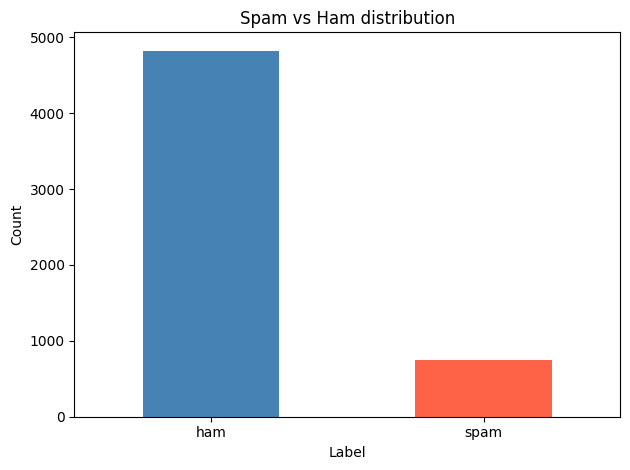

In [5]:
# Count each class
print(df['label'].value_counts())
print("\nAs percentages:")
print(df['label'].value_counts(normalize=True) * 100)

# Visualise it
df['label'].value_counts().plot(
    kind='bar',
    color=['steelblue', 'tomato'],
    title='Spam vs Ham distribution'
)
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.234197  58.084357   2.0   33.0   52.0   92.0  910.0
spam    747.0  139.340027  29.318159  13.0  133.0  150.0  158.0  225.0


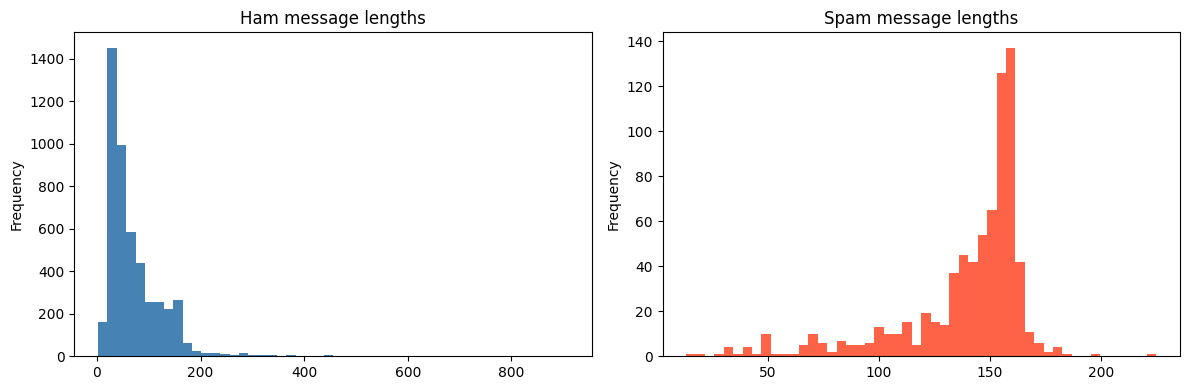

In [6]:
# Add a column for message length
df['length'] = df['text'].apply(len)

# Compare length between spam and ham
print(df.groupby('label')['length'].describe())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['label'] == 'ham']['length'].plot(
    kind='hist',
    bins=50,
    ax=axes[0],
    title='Ham message lengths',
    color='steelblue'
)

df[df['label'] == 'spam']['length'].plot(
    kind='hist',
    bins=50,
    ax=axes[1],
    title='Spam message lengths',
    color='tomato'
)

plt.tight_layout()
plt.show()

In [7]:
from collections import Counter

# Get all words from spam messages
spam_words = ' '.join(df[df['label'] == 'spam']['text']).split()
ham_words = ' '.join(df[df['label'] == 'ham']['text']).split()

# Count the most common words
spam_common = Counter(spam_words).most_common(20)
ham_common = Counter(ham_words).most_common(20)

print("Top 20 words in SPAM:")
for word, count in spam_common:
    print(f"  {word}: {count}")

print("\nTop 20 words in HAM:")
for word, count in ham_common:
    print(f"  {word}: {count}")

Top 20 words in SPAM:
  to: 604
  a: 358
  your: 187
  call: 185
  or: 185
  the: 178
  2: 169
  for: 169
  you: 164
  is: 143
  Call: 136
  on: 135
  have: 128
  and: 119
  from: 116
  ur: 107
  with: 101
  &: 98
  4: 93
  of: 93

Top 20 words in HAM:
  to: 1530
  you: 1458
  I: 1436
  the: 1019
  a: 969
  and: 738
  i: 736
  in: 734
  u: 645
  is: 638
  my: 619
  me: 537
  of: 498
  for: 475
  that: 398
  it: 375
  your: 373
  on: 352
  have: 346
  at: 333


In [8]:
print("Total messages:", len(df))
print("Duplicate messages:", df.duplicated().sum())
print("Duplicate spam:", df[df['label'] == 'spam'].duplicated().sum())
print("Duplicate ham:", df[df['label'] == 'ham'].duplicated().sum())

# Look at some duplicates
df[df.duplicated()].head()

Total messages: 5572
Duplicate messages: 403
Duplicate spam: 94
Duplicate ham: 309


,label,text,length
102,ham,As per your request 'Melle Melle (Oru Minnamin...,160
153,ham,As per your request 'Melle Melle (Oru Minnamin...,160
206,ham,"As I entered my cabin my PA said, '' Happy B'd...",156
222,ham,"Sorry, I'll call later",22
325,ham,No calls..messages..missed calls,32


In [9]:
# Check for very short messages
print("Messages with less than 5 characters:")
print(df[df['text'].str.len() < 5])

# Check for messages that are just numbers
print("\nSample of spam messages:")
for msg in df[df['label'] == 'spam']['text'].head(5):
    print(f"  '{msg}'")

print("\nSample of ham messages:")
for msg in df[df['label'] == 'ham']['text'].head(5):
    print(f"  '{msg}'")

Messages with less than 5 characters:
     label  text  length
260    ham   Yup       3
286    ham  Ok..       4
1611   ham   645       3
1924   ham    Ok       2
2181   ham   Ok.       3
2601   ham  Okie       4
2687   ham  Okie       4
3049   ham    Ok       2
3374   ham   :)        3
3490   ham   Ok.       3
3831   ham   Ok.       3
3899   ham  Okie       4
4012   ham   Ok.       3
4496   ham    Ok       2
5173   ham  U 2.       4
5188   ham  Okie       4
5268   ham   \ER       3
5357   ham    Ok       2
5471   ham   Yup       3

Sample of spam messages:
  'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's'
  'FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, ï¿½1.50 to rcv'
  'WINNER!! As a valued network customer you have been selected to receivea ï¿½900 prize reward! To claim call 09061701461

In [ ]:
## EDA Summary — What we found and what we'll do about it

### Finding 1: Useless columns
The dataset has 3 empty columns called Unnamed: 2, 3, 4.
Action: Drop them, rename v1 and v2 to label and text.

### Finding 2: Class imbalance
87% ham, 13% spam. Heavily imbalanced.
Action: Use class_weight='balanced' when training
so the model doesn't ignore the minority class.

### Finding 3: Spam messages are longer
Spam messages are consistently longer than ham.
Action: Add message length as an extra feature during preprocessing.

### Finding 4: Clear vocabulary difference
Spam uses words like free, call, win, prize.
Ham uses conversational words like ok, come, know.
Action: TF-IDF will capture this well. Remove stopwords first.

### Finding 5: Duplicate messages
There are duplicate messages in the dataset.
Action: Drop duplicates during preprocessing.

### Finding 6: Noise in text
Punctuation, capital letters, and stopwords add noise.
Action: Lowercase, remove punctuation, remove stopwords, stem.